In [2]:
import pandas as pd

df = pd.read_csv("../data/student-mat.csv", sep=';')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

print("\nFirst 5 rows:")
print(df.head())

print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

Shape: (395, 33)

Columns:
 Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

First 5 rows:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3 

In [3]:
df['risk'] = df['G3'].apply(lambda x: 1 if x < 10 else 0)


print(df['risk'].value_counts())


print("\nPercentage:\n", df['risk'].value_counts(normalize=True) * 100)

risk
0    265
1    130
Name: count, dtype: int64

Percentage:
 risk
0    67.088608
1    32.911392
Name: proportion, dtype: float64


In [4]:
max_absences = df['absences'].max()
df['attendance'] = 100 * (1 - df['absences'] / max_absences)


df['quiz_avg'] = (df['G1'] + df['G2']) / 2

df['trend'] = df['G2'] - df['G1']

print(df[['absences', 'attendance', 'G1', 'G2', 'quiz_avg', 'trend']].head())

   absences  attendance  G1  G2  quiz_avg  trend
0         6   92.000000   5   6       5.5      1
1         4   94.666667   5   5       5.0      0
2        10   86.666667   7   8       7.5      1
3         2   97.333333  15  14      14.5     -1
4         4   94.666667   6  10       8.0      4


In [5]:
max_absences = df['absences'].max()

In [6]:
y = df['risk']

X = df.drop(['risk', 'G3'], axis=1)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (395, 35)
Target shape: (395,)


In [7]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

le = LabelEncoder()

for col in X_encoded.columns:
    if not pd.api.types.is_numeric_dtype(X_encoded[col]):
        X_encoded[col] = le.fit_transform(X_encoded[col])

print(X_encoded.head())
print("\nData types:\n", X_encoded.dtypes)

   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15        1        1        1     1     1     0     2  ...   
3       0    0   15        1        0        1     4     2     1     3  ...   
4       0    0   16        1        0        1     3     3     2     2  ...   

   goout  Dalc  Walc  health  absences  G1  G2  attendance  quiz_avg  trend  
0      4     1     1       3         6   5   6   92.000000       5.5      1  
1      3     1     1       3         4   5   5   94.666667       5.0      0  
2      2     2     3       3        10   7   8   86.666667       7.5      1  
3      2     1     1       5         2  15  14   97.333333      14.5     -1  
4      2     1     2       5         4   6  10   94.666667       8.0      4  

[5 rows x 35 columns]

Data types:
 school          int6

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nClass distribution in train:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in test:")
print(y_test.value_counts(normalize=True))

X_train shape: (316, 35)
X_test shape: (79, 35)

Class distribution in train:
risk
0    0.670886
1    0.329114
Name: proportion, dtype: float64

Class distribution in test:
risk
0    0.670886
1    0.329114
Name: proportion, dtype: float64


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8987341772151899
Recall: 0.8076923076923077
F1 Score: 0.84

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.94      0.93        53
           1       0.88      0.81      0.84        26

    accuracy                           0.90        79
   macro avg       0.89      0.88      0.88        79
weighted avg       0.90      0.90      0.90        79



In [10]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8354430379746836
Recall: 0.7307692307692307
F1 Score: 0.7450980392156863

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.89      0.88        53
           1       0.76      0.73      0.75        26

    accuracy                           0.84        79
   macro avg       0.82      0.81      0.81        79
weighted avg       0.83      0.84      0.83        79



In [11]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.9240506329113924
Recall: 0.8846153846153846
F1 Score: 0.8846153846153846

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        53
           1       0.88      0.88      0.88        26

    accuracy                           0.92        79
   macro avg       0.91      0.91      0.91        79
weighted avg       0.92      0.92      0.92        79



/opt/anaconda3/envs/ml_project/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [11:39:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [12]:
y_prob = xgb_model.predict_proba(X_test)[:, 1]

risk_score = y_prob * 100

risk_df = X_test.copy()
risk_df['Actual'] = y_test.values
risk_df['Predicted'] = y_pred_xgb
risk_df['Risk Score'] = risk_score

print(risk_df[['Actual', 'Predicted', 'Risk Score']].head())

     Actual  Predicted  Risk Score
383       1          1   98.499199
19        0          0    6.276388
193       0          1   98.765198
343       1          1   62.904705
92        1          1   99.610764


In [13]:
def categorize_risk(score):
    if score <= 30:
        return "Low"
    elif score <= 70:
        return "Medium"
    else:
        return "High"

risk_df['Risk Level'] = risk_df['Risk Score'].apply(categorize_risk)

print(risk_df[['Actual', 'Predicted', 'Risk Score', 'Risk Level']].head())

     Actual  Predicted  Risk Score Risk Level
383       1          1   98.499199       High
19        0          0    6.276388        Low
193       0          1   98.765198       High
343       1          1   62.904705     Medium
92        1          1   99.610764       High


/opt/anaconda3/envs/ml_project/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/y4/xn4m0ssd79vb5yt7xv_nzpww0000gn/T/ipykernel_1138/704220165.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_array)


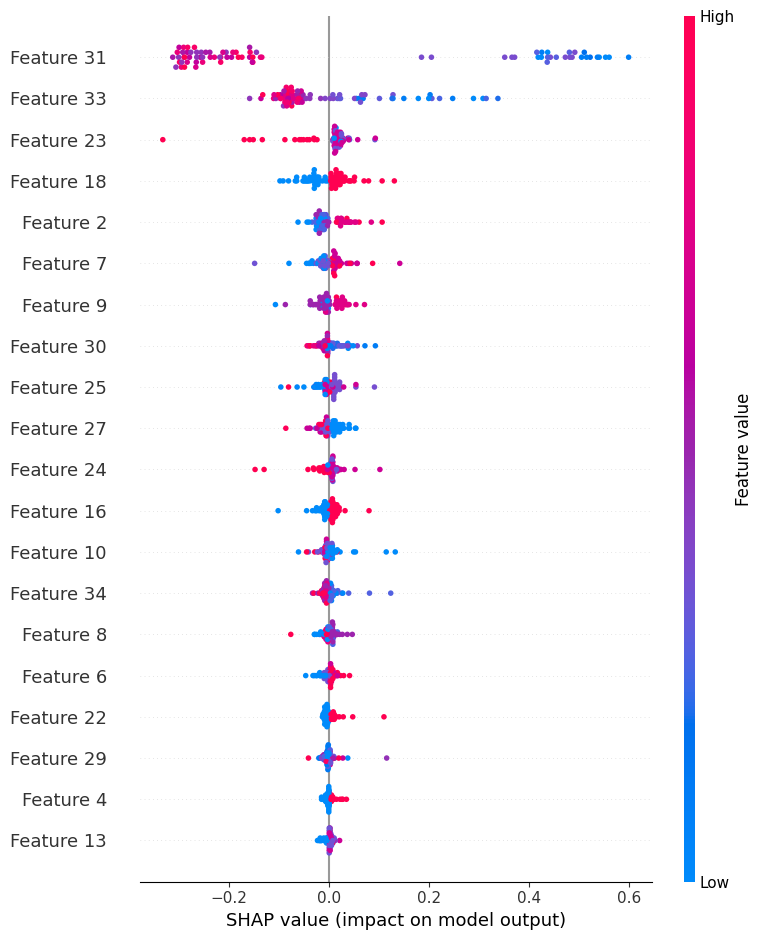

In [14]:
import shap
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (5, 3)
X_test_array = np.array(X_test, dtype=float)

explainer = shap.Explainer(xgb_model.predict, X_test_array)

shap_values = explainer(X_test_array)

shap.summary_plot(shap_values, X_test_array)

/var/folders/y4/xn4m0ssd79vb5yt7xv_nzpww0000gn/T/ipykernel_1138/2217823065.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)


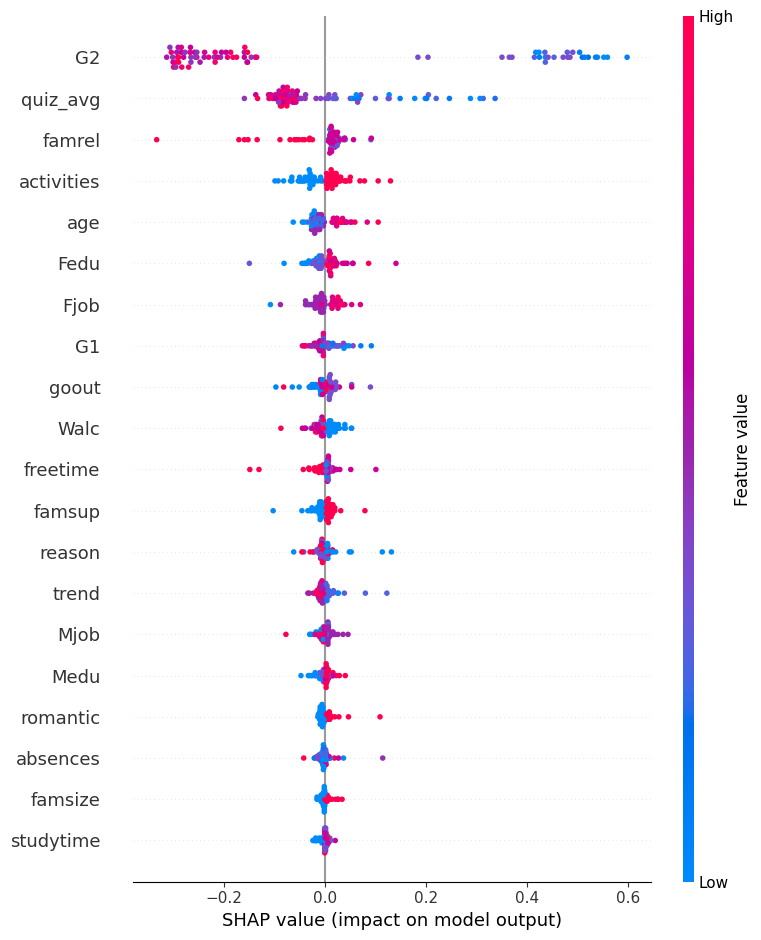

In [15]:
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

/var/folders/y4/xn4m0ssd79vb5yt7xv_nzpww0000gn/T/ipykernel_1138/3237810805.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


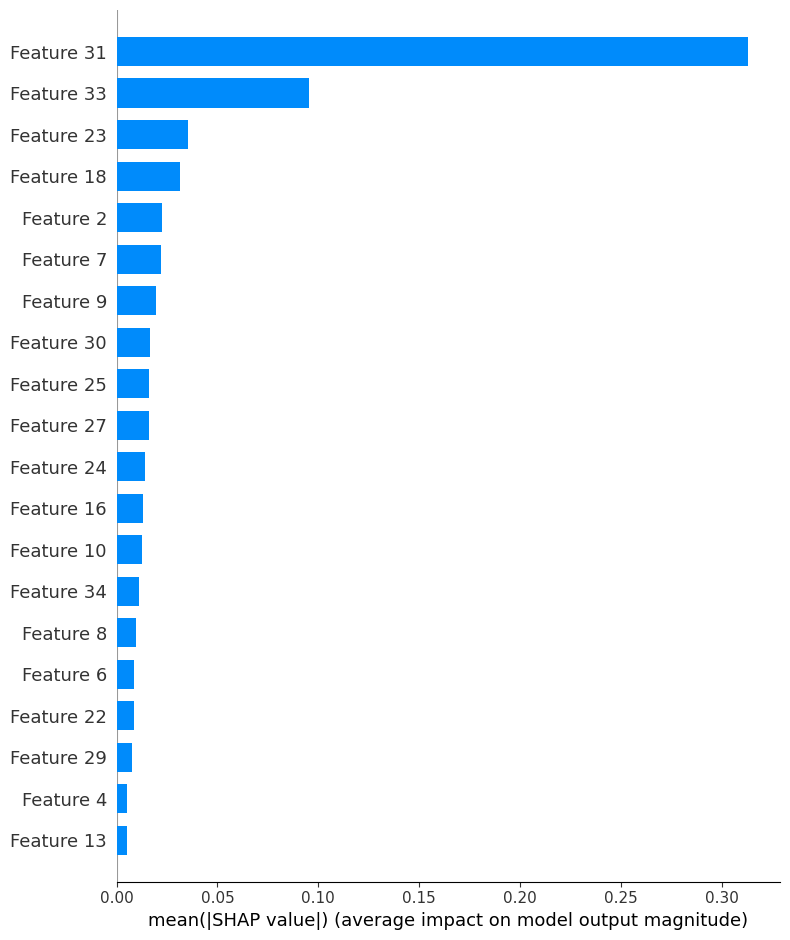

In [16]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [17]:
import numpy as np

feature_importance = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

       Feature  Importance
31          G2    0.313263
33    quiz_avg    0.095154
23      famrel    0.035365
18  activities    0.031462
2          age    0.022650
7         Fedu    0.021952
9         Fjob    0.019525
30          G1    0.016733
25       goout    0.016241
27        Walc    0.015886


In [18]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_encoded)

anomaly_labels = iso.predict(X_encoded)

df['anomaly'] = anomaly_labels

print(df['anomaly'].value_counts())

anomaly
 1    355
-1     40
Name: count, dtype: int64


In [19]:
comparison = pd.crosstab(df['risk'], df['anomaly'])

print(comparison)

anomaly  -1    1
risk            
0        19  246
1        21  109


In [20]:
def generate_intervention(row):
    if row['Risk Level'] == 'High':
        return "Immediate counseling & mentoring"
    elif row['Risk Level'] == 'Medium':
        return "Regular monitoring & academic support"
    elif row['Risk Level'] == 'Low' and row['anomaly'] == -1:
        return "Behavioral review (early warning)"
    else:
        return "No action needed"

risk_df = risk_df.merge(df[['anomaly']], left_index=True, right_index=True)

risk_df['Intervention'] = risk_df.apply(generate_intervention, axis=1)

print(risk_df[['Risk Score', 'Risk Level', 'anomaly', 'Intervention']].head())

     Risk Score Risk Level  anomaly                           Intervention
383   98.499199       High        1       Immediate counseling & mentoring
19     6.276388        Low        1                       No action needed
193   98.765198       High        1       Immediate counseling & mentoring
343   62.904705     Medium        1  Regular monitoring & academic support
92    99.610764       High        1       Immediate counseling & mentoring


In [21]:
import pandas as pd

importance = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))

     Feature  Importance
31        G2    0.420130
33  quiz_avg    0.052934
4    famsize    0.051287
6       Medu    0.032524
7       Fedu    0.032520
3    address    0.029768
21  internet    0.027512
30        G1    0.026035
2        age    0.025831
25     goout    0.025227


In [22]:

top_features = feature_importance_df['Feature'].head(10).tolist()

print("Selected Features:", top_features)

X_reduced = X_encoded[top_features]

from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Reduced X_train shape:", X_train_r.shape)

Selected Features: ['G2', 'quiz_avg', 'famsize', 'Medu', 'Fedu', 'address', 'internet', 'G1', 'age', 'goout']
Reduced X_train shape: (316, 10)


In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report

# Train model
xgb_reduced = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_reduced.fit(X_train_r, y_train_r)

# Predictions
y_pred_r = xgb_reduced.predict(X_test_r)

# Evaluation
print("Accuracy:", accuracy_score(y_test_r, y_pred_r))
print("Recall:", recall_score(y_test_r, y_pred_r))
print("F1 Score:", f1_score(y_test_r, y_pred_r))

print("\nClassification Report:\n")
print(classification_report(y_test_r, y_pred_r))

/opt/anaconda3/envs/ml_project/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [11:39:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8987341772151899
Recall: 0.8846153846153846
F1 Score: 0.8518518518518519

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.91      0.92        53
           1       0.82      0.88      0.85        26

    accuracy                           0.90        79
   macro avg       0.88      0.90      0.89        79
weighted avg       0.90      0.90      0.90        79



In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)
print(cm)

[[50  3]
 [ 3 23]]


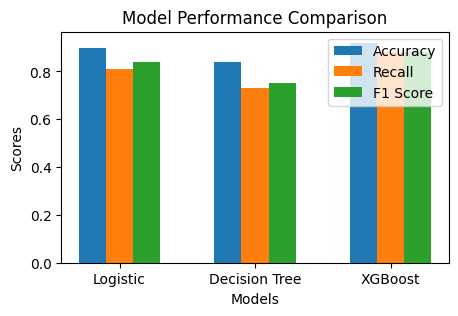

In [25]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic', 'Decision Tree', 'XGBoost']
accuracy = [0.90, 0.84, 0.92]
recall = [0.81, 0.73, 0.88]
f1 = [0.84, 0.75, 0.88]

x = np.arange(len(models))

plt.figure()
plt.bar(x - 0.2, accuracy, 0.2, label='Accuracy')
plt.bar(x, recall, 0.2, label='Recall')
plt.bar(x + 0.2, f1, 0.2, label='F1 Score')

plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("Scores")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()

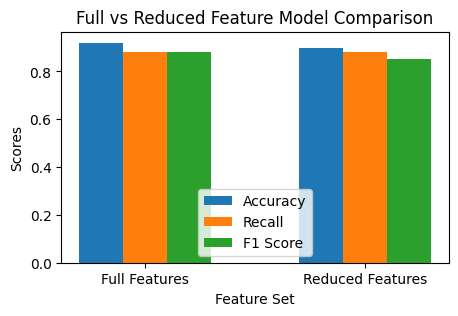

In [26]:
models = ['Full Features', 'Reduced Features']
accuracy = [0.92, 0.90]
recall = [0.88, 0.88]
f1 = [0.88, 0.85]

x = np.arange(len(models))

plt.figure()
plt.bar(x - 0.2, accuracy, 0.2, label='Accuracy')
plt.bar(x, recall, 0.2, label='Recall')
plt.bar(x + 0.2, f1, 0.2, label='F1 Score')

plt.xticks(x, models)
plt.xlabel("Feature Set")
plt.ylabel("Scores")
plt.title("Full vs Reduced Feature Model Comparison")
plt.legend()

plt.show()

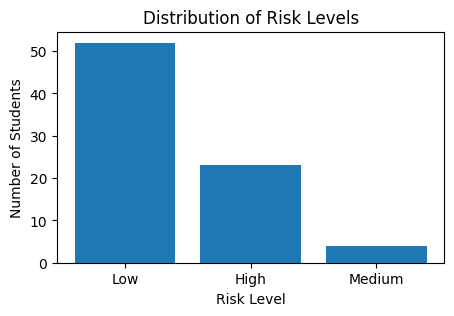

In [27]:
risk_counts = risk_df['Risk Level'].value_counts()

plt.figure()
plt.bar(risk_counts.index, risk_counts.values)

plt.xlabel("Risk Level")
plt.ylabel("Number of Students")
plt.title("Distribution of Risk Levels")

plt.show()

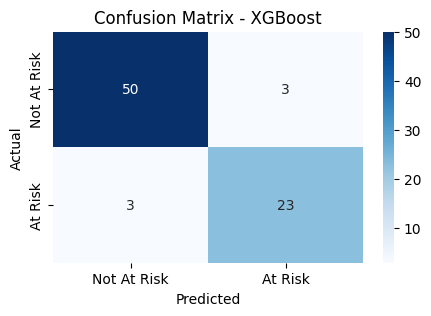

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not At Risk', 'At Risk'],
            yticklabels=['Not At Risk', 'At Risk'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')

plt.show()

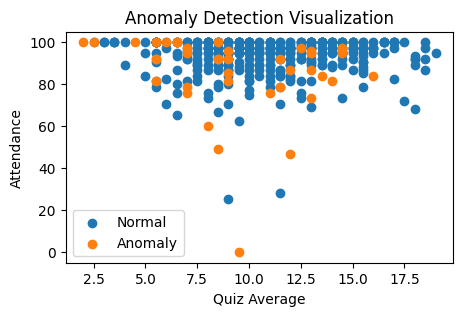

In [29]:
import matplotlib.pyplot as plt

plt.figure()

# Normal points
normal = df[df['anomaly'] == 1]
plt.scatter(normal['quiz_avg'], normal['attendance'], label='Normal')

# Anomalies
anomaly = df[df['anomaly'] == -1]
plt.scatter(anomaly['quiz_avg'], anomaly['attendance'], label='Anomaly')

plt.xlabel('Quiz Average')
plt.ylabel('Attendance')
plt.title('Anomaly Detection Visualization')

plt.legend()
plt.show()